<a href="https://colab.research.google.com/github/GINDRANADH/Internship/blob/main/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

--- Data Wrangling Complete ---
Cleaned Dataset Shape: (31, 7)

First 10 Rows:
   Duration       Date  Pulse  Maxpulse  Calories  Calories_Per_Min Intensity
0        60 2020-12-01    110       130     409.1              6.82      High
1        60 2020-12-02    117       145     479.0              7.98      High
2        60 2020-12-03    103       135     340.0              5.67  Moderate
3        45 2020-12-04    109       175     282.4              6.28  Moderate
4        45 2020-12-05    117       148     406.0              9.02      High
5        60 2020-12-06    102       127     300.0              5.00  Moderate
6        60 2020-12-07    110       136     374.0              6.23      High
7        45 2020-12-08    104       134     253.3              5.63  Moderate
8        30 2020-12-09    109       133     195.1              6.50  Moderate
9        60 2020-12-10     98       124     269.0              4.48       Low


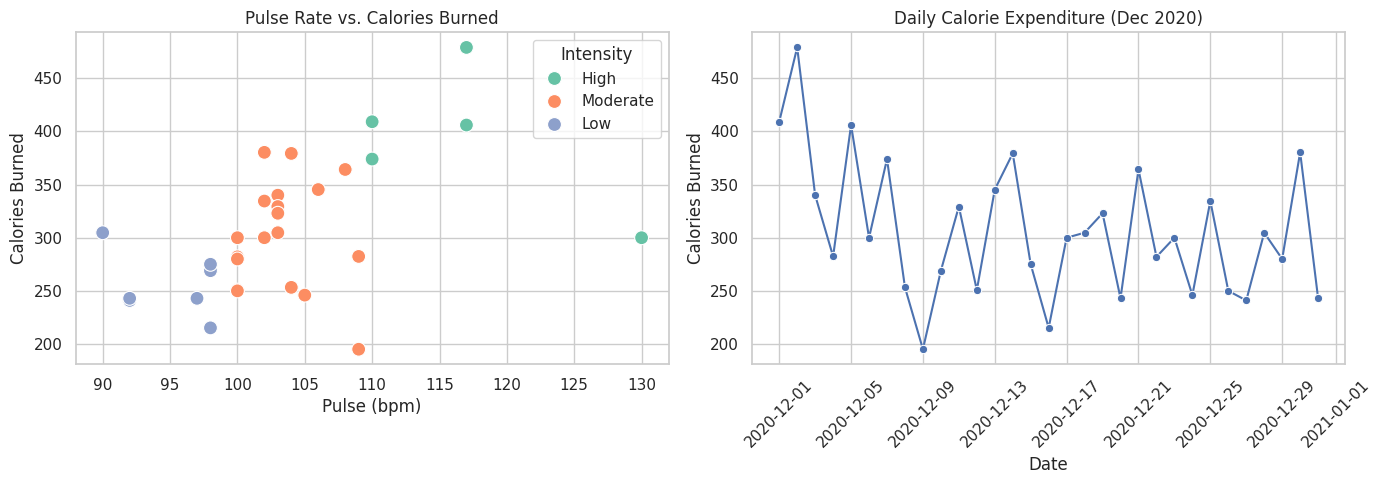

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read the local dataset
df = pd.read_csv('data.csv')

# 2. Fix Date Column (Remove quotes, standardize format, fill missing date)
df['Date'] = df['Date'].astype(str).str.replace("'", "").str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df.loc[df['Date'].isnull(), 'Date'] = pd.to_datetime('2020-12-22')

# 3. Fix Outlier (Duration = 450 is a typo for 45)
df.loc[df['Duration'] == 450, 'Duration'] = 45

# 4. Handle Missing Values in Calories (Impute with Mean)
df['Calories'] = df['Calories'].fillna(round(df['Calories'].mean(), 1))

# 5. Remove Duplicate Rows
df = df.drop_duplicates().reset_index(drop=True)

# 6. Feature Engineering (New Columns)
df['Calories_Per_Min'] = (df['Calories'] / df['Duration']).round(2)
df['Intensity'] = df['Pulse'].apply(lambda x: 'High' if x >= 110 else ('Moderate' if x >= 100 else 'Low'))

print("--- Data Wrangling Complete ---")
print("Cleaned Dataset Shape:", df.shape)
print("\nFirst 10 Rows:")
print(df.head(10))

# 7. Data Visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Pulse vs Calories Burned
sns.scatterplot(
    data=df,
    x='Pulse',
    y='Calories',
    hue='Intensity',
    palette='Set2',
    s=100,
    ax=axes[0]
)
axes[0].set_title('Pulse Rate vs. Calories Burned')
axes[0].set_xlabel('Pulse (bpm)')
axes[0].set_ylabel('Calories Burned')

# Plot B: Daily Calorie Burn Over Time
sns.lineplot(
    data=df,
    x='Date',
    y='Calories',
    marker='o',
    color='b',
    ax=axes[1]
)
axes[1].set_title('Daily Calorie Expenditure (Dec 2020)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Calories Burned')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()